In [18]:
import pandas as pd

file_path = "../data/01-raw_data/Toronto_island_ferry_ticket_counts.csv"

# Load via pandas to handle quoted commas correctly
df = pd.read_csv(file_path)

df.rename(columns={'Redemption Count': 'Redemption_Count'}, inplace=True)
df.rename(columns={'Sales Count': 'Sales_Count'}, inplace=True)

# Convert DataFrame to structured NumPy array
data = df.to_records(index=False)

print("Loaded successfully!")
print("Shape:", data.shape)
print("Columns:", data.dtype.names)
print(data[:5])

Loaded successfully!
Shape: (32000,)
Columns: ('Unnamed: 0', '_id', 'Timestamp', 'Redemption_Count', 'Sales_Count')
[(1, 1, '2026-08-22T10:45:00',   9,   2)
 (2, 2, '2026-08-22T10:30:00', 331, 274)
 (3, 3, '2026-08-22T10:15:00', 277, 199)
 (4, 4, '2026-08-22T10:00:00', 248, 154)
 (5, 5, '2026-08-22T09:45:00', 200, 181)]


In [19]:
df = df.drop(columns="Unnamed: 0")

In [20]:
df.head()

,_id,Timestamp,Redemption_Count,Sales_Count
0,1,2026-08-22T10:45:00,9,2
1,2,2026-08-22T10:30:00,331,274
2,3,2026-08-22T10:15:00,277,199
3,4,2026-08-22T10:00:00,248,154
4,5,2026-08-22T09:45:00,200,181


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   _id               32000 non-null  int64 
 1   Timestamp         32000 non-null  object
 2   Redemption_Count  32000 non-null  int64 
 3   Sales_Count       32000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1000.1+ KB


In [22]:
df.describe()

,_id,Redemption_Count,Sales_Count
count,32000.000000,32000.000000,32000.000000
mean,16000.500000,73.412250,74.440219
std,9237.748643,136.923426,135.320037
min,1.000000,0.000000,0.000000
25%,8000.750000,4.000000,5.000000
50%,16000.500000,17.000000,22.000000
75%,24000.250000,82.000000,93.000000
max,32000.000000,5256.000000,5218.000000


In [24]:
date_col = "Timestamp"  
df[date_col] = pd.to_datetime(df[date_col])

# 2. Extract Year-Month (e.g., '2026-08')
df["Date"] = df[date_col].dt.to_period("M")

# 3. Aggregate totals by Year-Month
monthly_totals = df.groupby("Date")[["Redemption_Count", "Sales_Count"]].sum().reset_index()

print(monthly_totals)

       Date  Redemption_Count  Sales_Count
0   2025-06            102757       104945
1   2025-07            365303       370626
2   2025-08            380782       385275
3   2025-09            166671       162632
4   2025-10             85523        81714
5   2025-11             29496        25551
6   2025-12             18433        14929
7   2026-01             17745        14572
8   2026-02             25024        27866
9   2026-03             28050        24298
10  2026-04             54883        53046
11  2026-05            153994       154571
12  2026-06            239846       243753
13  2026-07            358511       361130
14  2026-08            322174       357179


C:\Users\Kyle_\AppData\Local\Temp\ipykernel_41420\495386993.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


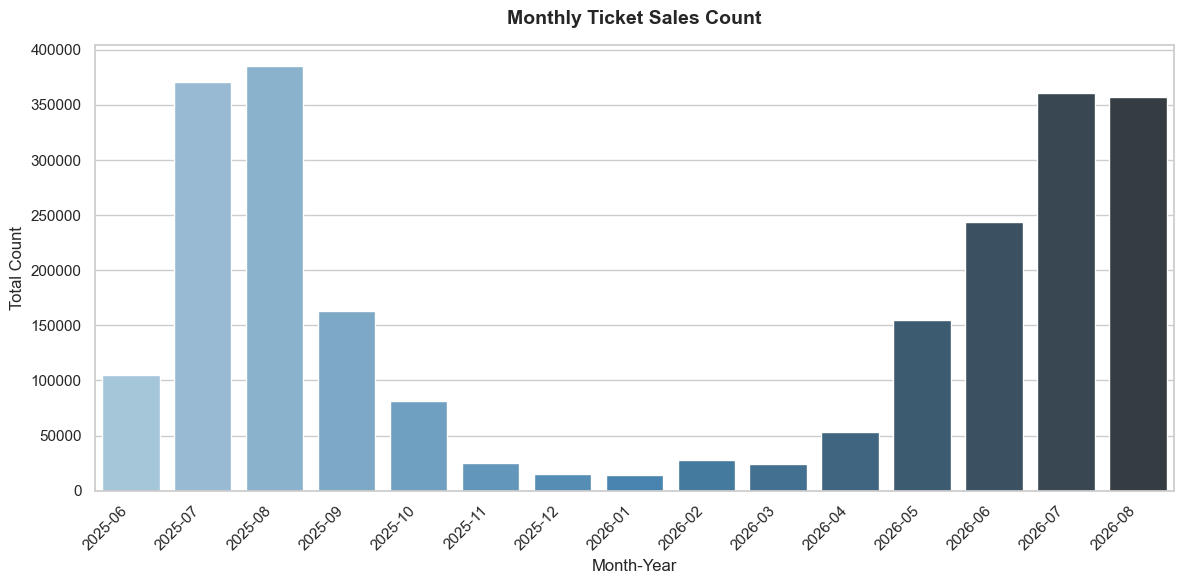

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plot bar chart (adjust x and y to your column names)
ax = sns.barplot(
    data=monthly_totals,
    x="Date",
    y="Sales_Count",
    palette="Blues_d"
)

# Format titles and labels
plt.title("Monthly Ticket Sales Count", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Month-Year", fontsize=12)
plt.ylabel("Total Count", fontsize=12)

# Rotate X-axis labels so dates don't overlap
plt.xticks(rotation=45, ha="right")

# Add layout spacing and display
plt.tight_layout()
plt.show()

C:\Users\Kyle_\AppData\Local\Temp\ipykernel_41420\3848395432.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


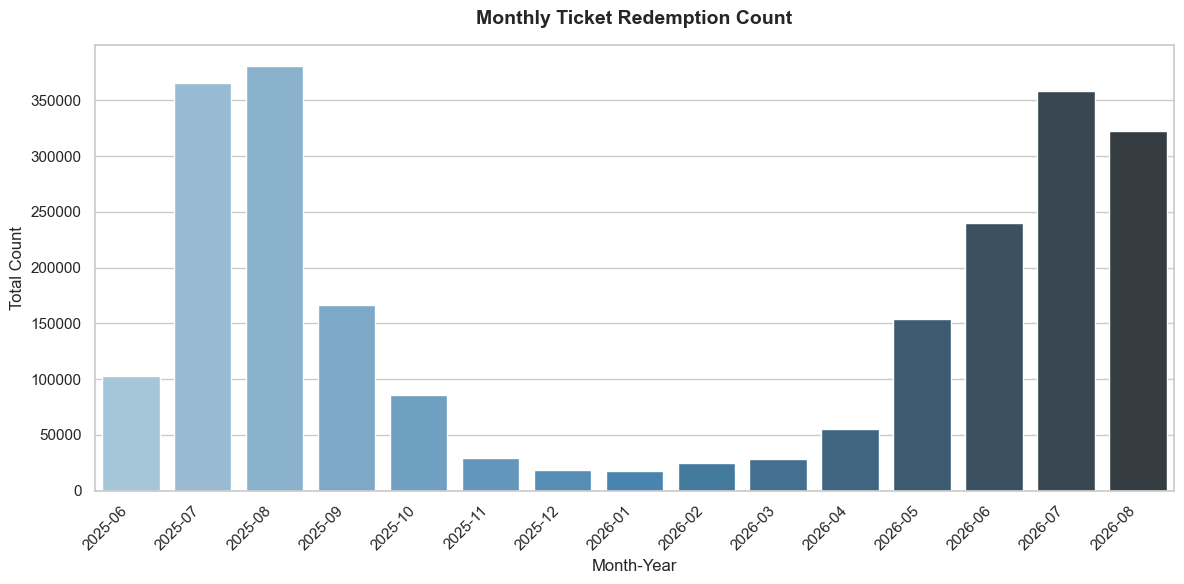

In [26]:

# Set clean aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plot bar chart (adjust x and y to your column names)
ax = sns.barplot(
    data=monthly_totals,
    x="Date",
    y="Redemption_Count",
    palette="Blues_d"
)

# Format titles and labels
plt.title("Monthly Ticket Redemption Count", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Month-Year", fontsize=12)
plt.ylabel("Total Count", fontsize=12)

# Rotate X-axis labels so dates don't overlap
plt.xticks(rotation=45, ha="right")

# Add layout spacing and display
plt.tight_layout()
plt.show()